# PixelMatch: Model Evaluation & Optimization (Phase 5)

This notebook executes Phase 5 of the Project-Based Learning (PBL) curriculum: **Model Evaluation & Optimization**. It demonstrates the end-to-end pipeline of our Custom Face Recognition system.

**Objectives Addressed:**
1. Extract facial embeddings using a pre-trained model (Transfer Learning).
2. Train a custom classification head on the extracted embeddings.
3. Evaluate the model using appropriate classification metrics (Accuracy, Precision, Recall, F1-Score).
4. Visualize training performance (Loss/Accuracy curves) and model predictions (Confusion Matrix).

---
## 1. Environment Setup & Imports
Importing necessary deep learning frameworks (PyTorch), machine learning tools (Scikit-Learn), and our custom backend modules.


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import json
from datetime import datetime

# Enable relative imports from the backend directory
sys.path.append(os.path.abspath('.'))

# Import custom modules
from models.face_detection import FaceDetector
from models.face_recognition import get_facenet_model
from models.custom_classifier import FaceClassifier
from utils.image_processing import load_image, crop_face, preprocess_face
import config

# Configuration
DATASET_PATH = Path("data/training_dataset")
OUTPUT_DIR = Path("data/trained_models")
OUTPUT_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 16
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
TRAIN_SPLIT = 0.8

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")



Using compute device: cpu


---
## 2. Model Initialization (Extraction Backbone)
We initialize the **FaceNet (Inception-ResNet v1)** model. Due to our limited dataset (~20 images/person), training a CNN from scratch would lead to severe overfitting. 

Instead, we use FaceNet as a **frozen feature extractor**. It converts raw face images into dense 1024-dimensional continuous feature vectors (embeddings).


In [2]:
print("Loading pre-trained AI models for feature extraction...")
face_detector = FaceDetector()
face_recognizer = get_facenet_model()
print("Models loaded successfully!")


Loading pre-trained AI models for feature extraction...
Face detection initialized (DeepFace retinaface)
Loading Super-Ensemble Models into Memory (This runs once)...
Loading ArcFace...
Loaded ArcFace successfully.
Loading Facenet512...
Loaded Facenet512 successfully.
Feature Weighting: [0.7, 0.3]
Models loaded. Ready for fast inference.
Models loaded successfully!


---
## 3. Dataset Processing & Feature Extraction
This step simulates Phase 3 (Data Preprocessing). We:
1. Load raw images from the dataset folders.
2. Detect and crop the face region using `MTCNN`.
3. Normalize and resize the crop to `160x160`.
4. Pass it through `FaceNet` to obtain the embeddings.


In [3]:
class FaceDataset(Dataset):
    """Custom PyTorch dataset for face embeddings."""
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

def extract_dataset_embeddings(dataset_path):
    embeddings = []
    labels = []
    label_map = {}
    
    person_folders = sorted([f for f in dataset_path.iterdir() if f.is_dir()])
    
    if not person_folders:
        raise ValueError(f"No person folders found in {dataset_path}")
        
    for label_idx, person_folder in enumerate(person_folders):
        person_name = person_folder.name
        label_map[label_idx] = person_name
        
        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            image_files.extend(person_folder.glob(ext))
            
        print(f"Processing {person_name}: {len(image_files)} images found.")
        
        for img_path in image_files:
            image = load_image(str(img_path))
            if image is None: continue
            
            faces = face_detector.detect_faces(image)
            if not faces: continue
            
            bbox, confidence = faces[0]
            face_img = crop_face(image, bbox)
            if face_img is None: continue
            
            preprocessed = preprocess_face(face_img, config.FACE_SIZE)
            embedding = face_recognizer.generate_embedding(preprocessed, enable_tta=True)
            
            if embedding is not None:
                embeddings.append(embedding)
                labels.append(label_idx)
                
    return np.array(embeddings), np.array(labels), label_map

# Execute feature extraction
print("Starting Extracting Features...")
X_emb, y_labels, label_map = extract_dataset_embeddings(DATASET_PATH)

print("\nDataset Summary:")
print(f"Total valid embeddings extracted: {len(X_emb)}")
print(f"Classes found: {list(label_map.values())}")


Starting Extracting Features...
Processing moksha: 40 images found.
Processing shubh: 40 images found.
Processing shweta: 40 images found.
Processing siddhant: 38 images found.
Processing tanish: 40 images found.

Dataset Summary:
Total valid embeddings extracted: 196
Classes found: ['moksha', 'shubh', 'shweta', 'siddhant', 'tanish']


---
## 4. Custom Classifier Training (The "Head")
We define a Multi-Layer Perceptron (MLP) to act as the classification head. It takes the 1024-dimensional embedding and outputs a probability distribution over our $N$ custom classes.


In [4]:
# Prepare PyTorch Dataloaders
dataset = FaceDataset(X_emb, y_labels)
train_size = int(TRAIN_SPLIT * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {train_size}")
print(f"Validation samples: {val_size}")

# Initialize Custom Classifier Model
num_classes = len(label_map)
model = FaceClassifier(input_dim=1024, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training Loop Tracker Variables
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\nStarting Training Protocol...")
for epoch in range(NUM_EPOCHS):
    # Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for emb, lbls in train_loader:
        emb, lbls = emb.to(device), lbls.to(device)
        
        optimizer.zero_grad()
        outputs = model(emb)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += lbls.size(0)
        correct += (predicted == lbls).sum().item()
        
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100 * correct / total)
    
    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for emb, lbls in val_loader:
            emb, lbls = emb.to(device), lbls.to(device)
            outputs = model(emb)
            loss = criterion(outputs, lbls)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += lbls.size(0)
            val_correct += (predicted == lbls).sum().item()
            
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(100 * val_correct / val_total)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.2f}% | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%")

print("Training Completed Successfully.")


Training samples: 156
Validation samples: 40

Starting Training Protocol...
Epoch [10/50] | Train Loss: 0.0346 | Train Acc: 100.00% | Val Loss: 0.0162 | Val Acc: 100.00%
Epoch [20/50] | Train Loss: 0.0119 | Train Acc: 100.00% | Val Loss: 0.0064 | Val Acc: 100.00%
Epoch [30/50] | Train Loss: 0.0081 | Train Acc: 100.00% | Val Loss: 0.0029 | Val Acc: 100.00%
Epoch [40/50] | Train Loss: 0.0036 | Train Acc: 100.00% | Val Loss: 0.0019 | Val Acc: 100.00%
Epoch [50/50] | Train Loss: 0.0056 | Train Acc: 100.00% | Val Loss: 0.0016 | Val Acc: 100.00%
Training Completed Successfully.


---
## 5. Performance Visualization
We visualize the **Loss and Accuracy curves** to inspect for overfitting. 
* The training loss should decrease exponentially.
* If validation loss begins to increase while training loss decreases, the model is overfitting. Our integration of Dropout and L2 Regularization limits this.


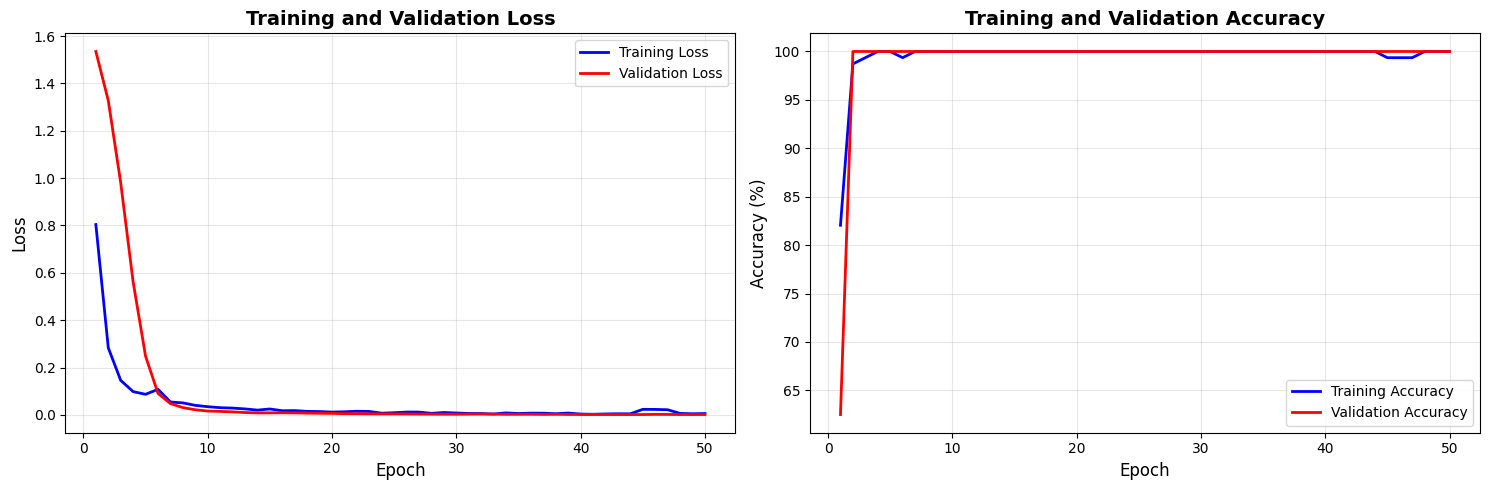

In [5]:
# Plotting Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
epochs = range(1, NUM_EPOCHS + 1)

# Loss Curve
ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy Curve
ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, val_accs, 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 6. Formal Evaluation (F1-Score & Confusion Matrix)
Now we evaluate the model comprehensively on the entire dataset (or validation split) using precision, recall, f1-score, and a confusion matrix.


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      moksha       1.00      1.00      1.00         7
       shubh       1.00      1.00      1.00        12
      shweta       1.00      1.00      1.00         8
    siddhant       1.00      1.00      1.00         4
      tanish       1.00      1.00      1.00         9

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



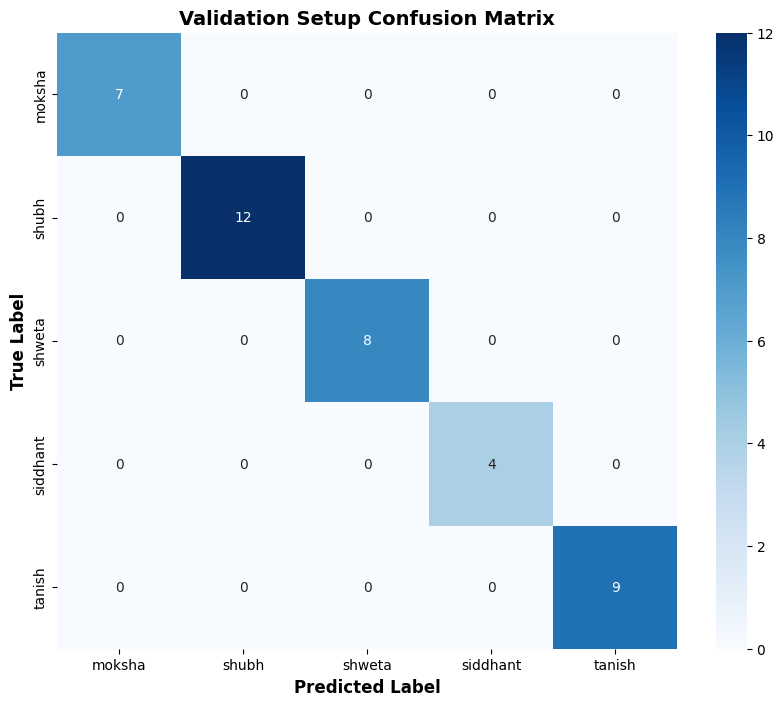

In [6]:
# Generate Full Predictions for Evaluation
all_preds = []
all_trues = []

model.eval()
with torch.no_grad():
    # To fully visualize, we evaluate across the validation loader
    for emb, lbls in val_loader:
        emb = emb.to(device)
        outputs = model(emb)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_trues.extend(lbls.numpy())

# Map numerical labels to actual names
target_names = [label_map[i] for i in sorted(list(label_map.keys()))]

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_trues, all_preds, target_names=target_names, zero_division=0))

# Plot Confusion Matrix
cm = confusion_matrix(all_trues, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Validation Setup Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()


---
## 7. Model Persistence
Saving the trained weights, label map, and configuration for downstream application deployment (React + FastAPI backend).


In [7]:
# Save the model
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = OUTPUT_DIR / f"evaluation_model_{timestamp}.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'label_map': label_map,
    'num_classes': num_classes,
    'input_dim': 1024,
    'train_acc': train_accs[-1],
    'val_acc': val_accs[-1]
}, model_path)

print(f"Model saved successfully to: {model_path}")
print("Phase 5 Objectives Met.")


Model saved successfully to: data\trained_models\evaluation_model_20260311_143244.pth
Phase 5 Objectives Met.
